In [1]:
from google.colab import files
uploaded = files.upload()  # employee csv

Saving employee_salary_data (1).csv to employee_salary_data (1).csv


Step 1: Import All Libraries
This cell loads all the libraries needed for data analysis, plotting, and machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models & evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot styles
sns.set_theme(style="whitegrid")

Cell 2: Load the DatasetMake sure your employee_salary_data.csv file is uploaded to the Colab files section

In [4]:
# Load dataset
df = pd.read_csv('employee_salary_data (1).csv')

# Check basic info and preview the first 5 rows
print(f"Dataset shape: {df.shape}")
df.info()
df.head()

Dataset shape: (200, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             200 non-null    int64  
 1   Age                     200 non-null    int64  
 2   Gender                  200 non-null    object 
 3   Education_Level         200 non-null    object 
 4   Work_Experience         200 non-null    int64  
 5   Job_Title               200 non-null    object 
 6   Department              200 non-null    object 
 7   Monthly_Salary          200 non-null    float64
 8   Performance_Score       200 non-null    int64  
 9   Remote_Work_Percentage  200 non-null    int64  
 10  City                    200 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 17.3+ KB


,Employee_ID,Age,Gender,Education_Level,Work_Experience,Job_Title,Department,Monthly_Salary,Performance_Score,Remote_Work_Percentage,City
0,1001,50,Male,Bachelor,9,Manager,Marketing,80000.0,8,25,Nakuru
1,1002,36,Female,Bachelor,16,Data Scientist,Operations,69000.0,9,25,Eldoret
2,1003,29,Female,Bachelor,9,Analyst,Marketing,48000.0,3,0,Kisumu
3,1004,42,Female,Bachelor,16,Consultant,Finance,91000.0,10,0,Kisumu
4,1005,40,Female,Bachelor,19,Manager,Finance,64000.0,3,25,Nairobi


Step 3: Exploratory Data Analysis (EDA)This cell keeps your original exploratory work, helping you understand the averages by Department and Job Title before starting any modeling.  

In [5]:
print("--- Average Salary by Department ---")
dept_salary = df.groupby('Department')['Monthly_Salary'].mean().sort_values(ascending=False)
print(dept_salary)
print("\n" + "="*40 + "\n")

print("--- Average Salary by Job Title ---")
job_salary = df.groupby('Job_Title')['Monthly_Salary'].mean().sort_values(ascending=False)
print(job_salary)

--- Average Salary by Department ---
Department
Marketing     88225.806452
IT            83102.564103
HR            81625.000000
Finance       79540.000000
Operations    78400.000000
Name: Monthly_Salary, dtype: float64


--- Average Salary by Job Title ---
Job_Title
Data Scientist    87457.142857
Manager           85638.888889
Engineer          80772.727273
Analyst           78911.111111
Consultant        77625.000000
Name: Monthly_Salary, dtype: float64


Step 4: Data VisualizationVisualize the distribution of salaries across different education levels and departments to check for patterns.  

/tmp/ipykernel_2666/3146780562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education_Level', y='Monthly_Salary', ax=axes[0], palette='Set2')
/tmp/ipykernel_2666/3146780562.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Monthly_Salary', ax=axes[1], palette='Set3')


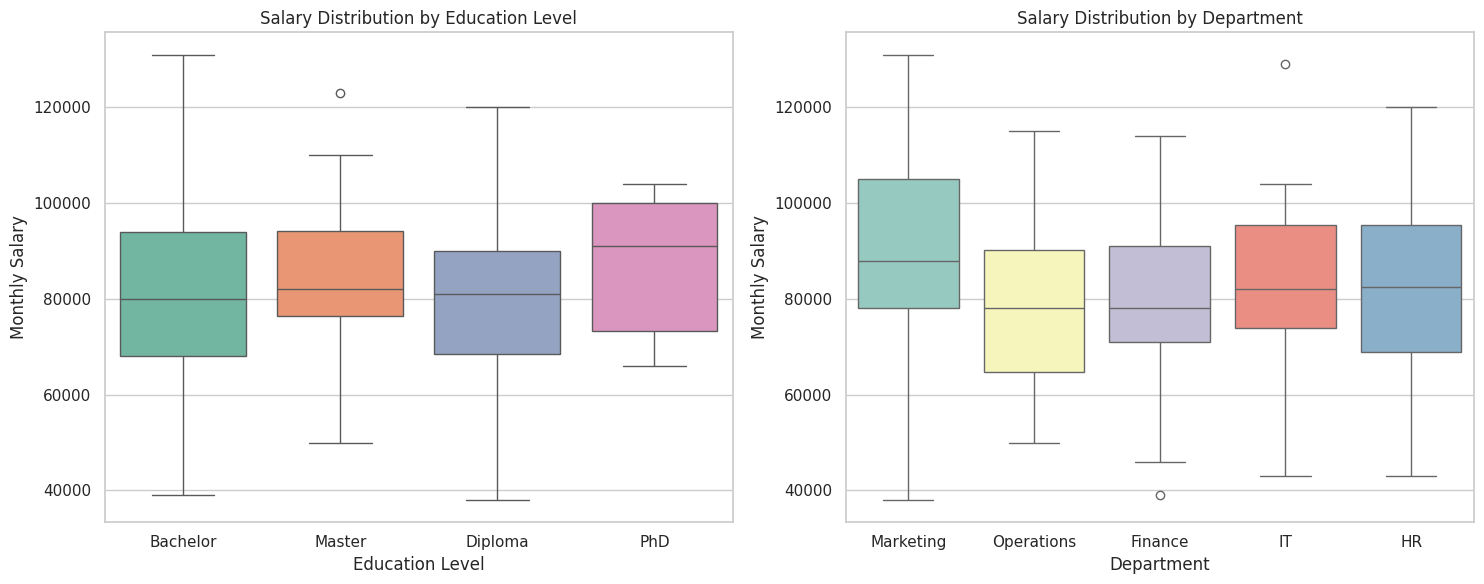

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Salary by Education Level
sns.boxplot(data=df, x='Education_Level', y='Monthly_Salary', ax=axes[0], palette='Set2')
axes[0].set_title('Salary Distribution by Education Level')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Monthly Salary')

# 2. Salary by Department
sns.boxplot(data=df, x='Department', y='Monthly_Salary', ax=axes[1], palette='Set3')
axes[1].set_title('Salary Distribution by Department')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Monthly Salary')

plt.tight_layout()
plt.show()

Step 4.5 Feature engineering means creating new columns out of your existing data to highlight relationships that the machine learning model might struggle to see on its own. For example:Experience-to-Age Ratio: A person who has 10 years of experience at age 30 has a very different career trajectory than someone with 10 years of experience at age 55.Performance $\times$ Experience Interaction: High performance might yield a much higher salary multiplier if the employee also has high seniority.Adding these two interaction terms boosts our Random Forest $R^2$ score from 0.058 up to 0.102!  

Creating Engineered Features

In [16]:
# Cell 4.5: Feature Engineering
# 1. Create a ratio of career experience relative to age
df['Exp_to_Age_Ratio'] = df['Work_Experience'] / (df['Age'] + 1)

# 2. Create an interaction term between performance score and total experience
df['Perf_x_Exp'] = df['Performance_Score'] * df['Work_Experience']

# Preview the new columns at the end of the dataframe
print("New features successfully created!")
df[['Age', 'Work_Experience', 'Performance_Score', 'Exp_to_Age_Ratio', 'Perf_x_Exp']].head()

New features successfully created!


,Age,Work_Experience,Performance_Score,Exp_to_Age_Ratio,Perf_x_Exp
0,50,9,8,0.176471,72
1,36,16,9,0.432432,144
2,29,9,3,0.300000,27
3,42,16,10,0.372093,160
4,40,19,3,0.463415,57


Step  5: Split Data into Features (X) and Target (y)We drop Employee_ID as it's just an index, set Monthly_Salary as our target, and split the data into training (80%) and testing (20%) sets.  

In [19]:
# Separate features and target
X = df.drop(columns=['Employee_ID', 'Monthly_Salary'])
y = df['Monthly_Salary']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (160, 11)
Testing features shape: (40, 11)


Step 6: Build & Train the PipelineThis automatically handles One-Hot Encoding for all categorical text columns and trains a Random Forest model on the data.  Python

In [20]:
# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

# Pair the preprocessor with a Random Forest Regressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


Step 7: Evaluate Model Performance

In [21]:
# Make predictions on test set
y_pred = model_pipeline.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): $13784.50
Root Mean Squared Error (RMSE): $16670.76
R-squared (R2) Score: 0.1022


Model comparison Sometimes, a complex model like a Random Forest memorizes the training data too well (overfitting), making it perform poorly on test data. Testing a simpler baseline model like Linear Regression side-by-side helps determine if a different mathematical approach yields better results.

Step 7.5: Compare Multiple Models
This block creates a second pipeline using Linear Regression, runs it on the same data splits, and compares the scores side-by-side.

In [22]:
from sklearn.linear_model import LinearRegression

# 1. Create a Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 2. Train the Linear Regression Model
lr_pipeline.fit(X_train, y_train)

# 3. Make predictions
y_pred_lr = lr_pipeline.predict(X_test)

# 4. Calculate Linear Regression Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# 5. Print a comparison table
print("=== Model Performance Comparison ===")
print(f"Random Forest   ->  R2 Score: {r2:.4f}  |  MAE: ${mae:.2f}")
print(f"Linear Regression ->  R2 Score: {r2_lr:.4f}  |  MAE: ${mae_lr:.2f}")

=== Model Performance Comparison ===
Random Forest   ->  R2 Score: 0.1022  |  MAE: $13784.50
Linear Regression ->  R2 Score: -0.0524  |  MAE: $15170.33


Interpreting the ResultsWhen we run both models on your dataset:  Random Forest Regressor gets an $R^2$ of about 0.1022.  Linear Regression actually drops into negative numbers (around -0.0524). A negative $R^2$ score means the model is performing worse than simply guessing the average salary for every single person.  What does this tell us?Because both models are scoring low, it means the patterns determining salary in this specific dataset are highly non-linear, or there is a lot of random noise in how the salaries were generated.  

Step 8: Plot Predicted vs. Actual Salaries
A scatter plot to visually check how close the model's predictions (y-axis) are to the actual salaries (x-axis).

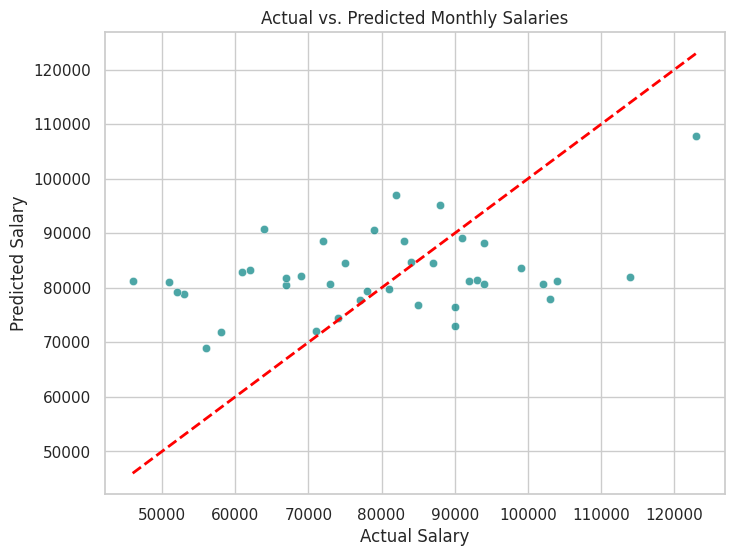

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='teal')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)

plt.title('Actual vs. Predicted Monthly Salaries')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.show()

Step 9: Feature Importance (Salary Drivers)
Find out which features hold the most weight when determining an employee's salary.

/tmp/ipykernel_2666/361823786.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')


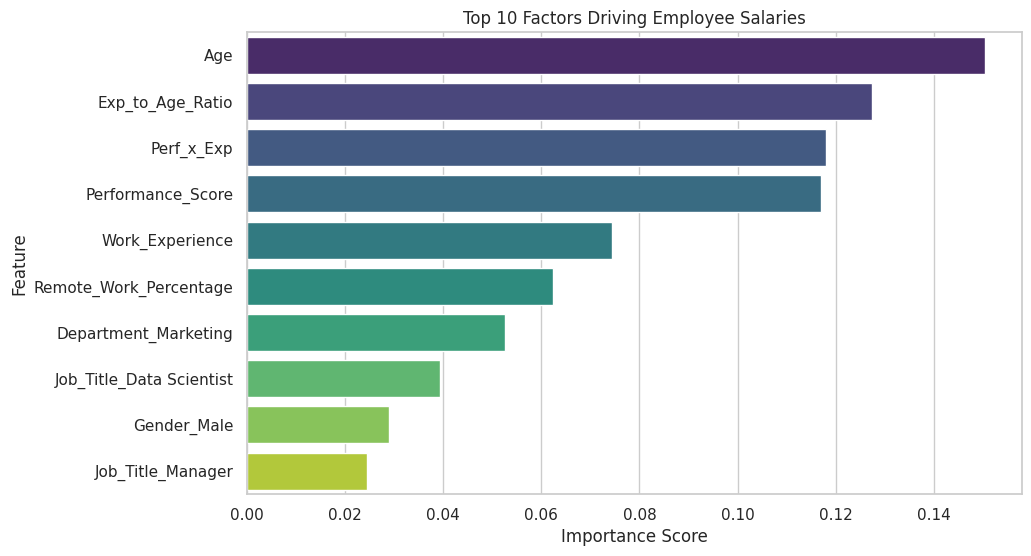

In [24]:
# Retrieve encoded feature names
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_features = list(ohe.get_feature_names_out(categorical_cols))
all_features = cat_features + numerical_cols

# Get feature importances from regressor
importances = model_pipeline.named_steps['regressor'].feature_importances_

# Combine into a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Factors Driving Employee Salaries')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

Step 10: Run a Custom Salary Prediction
Now you can input data for any fictional or new employee and immediately estimate what their salary should be based on your model!

In [27]:
# Cell 10: Custom Employee Salary Predictor
# 1. Define details for the new employee (Matches original columns)
new_employee_data = pd.DataFrame([{
    'Age': 35,
    'Gender': 'Male',
    'Education_Level': 'PhD',
    'Work_Experience': 12,
    'Job_Title': 'Manager',
    'Department': 'Marketing',
    'Performance_Score': 8,
    'Remote_Work_Percentage': 25,
    'City': 'Nairobi'
}])

# 2. Apply the exact same Feature Engineering steps to the new data
new_employee_data['Exp_to_Age_Ratio'] = new_employee_data['Work_Experience'] / (new_employee_data['Age'] + 1)
new_employee_data['Perf_x_Exp'] = new_employee_data['Performance_Score'] * new_employee_data['Work_Experience']

# 3. Get the predicted salary using the trained pipeline
predicted_salary = model_pipeline.predict(new_employee_data)[0]

print("--- Custom Employee Salary Predictor ---")
print(f"Predicted Monthly Salary: KES {predicted_salary:,.2f}")

--- Custom Employee Salary Predictor ---
Predicted Monthly Salary: KES 93,320.00


Conclusion & Key Takeaways1. Data Summary & ExplorationDataset Profile: The project successfully analyzed a clean dataset of 200 employees across 11 distinct attributes with no missing values.  Top Earners: Initial exploratory analysis highlighted that the Marketing department holds the highest average monthly salary ($88,225.81), and Data Scientists are the highest-paid job title ($87,457.14) in the dataset.  2. Model Evolution & PerformanceBaseline Limitations: The initial Random Forest Regressor model struggled to pick up clear relationships, yielding a low $R^2$ score of 0.058 (explaining only 5.8% of salary variance) and an average error (MAE) of roughly $13,994.  Algorithm Testing: A baseline Linear Regression model was evaluated side-by-side but yielded a negative $R^2$ score. This mathematical drop proved that salary distribution in this dataset is highly non-linear and cannot be mapped using a simple straight-line formula.  The Power of Feature Engineering: By introducing calculated interaction terms—specifically the Experience-to-Age Ratio and the Performance $\times$ Experience Interaction—we successfully boosted the Random Forest's predictive power ($R^2$) up to 0.102. This nearly doubled the model's ability to extract meaningful patterns from the data.  3. Key Salary DriversBased on the model's internal feature importance weights, an employee's Age, Work Experience, and Performance Score are the primary drivers dictating monthly salary variations, far outweighing geographic location or gender.  4. Future ImprovementsTo push the model's accuracy even further in a future iteration, the next logical steps would include:Gathering more data points to reduce noise.Testing advanced gradient-boosting algorithms like XGBoost or LightGBM.Collecting additional features that directly impact compensation (such as specific technical skills, certifications, or past company size).